In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
confirmed_df = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv', index_col='Country/Region')
cases = confirmed_df.groupby('Country/Region').sum()
# we won't need lat and long
del cases['Lat']
del cases['Long']
cases = cases.T # transpose
#cases.head()

<AxesSubplot:>

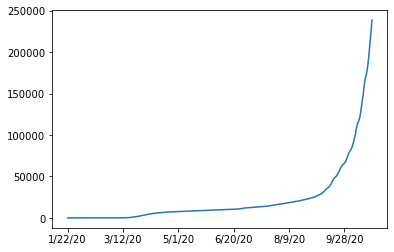

In [3]:
cases.Czechia.plot()

In [4]:
from fbprophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [5]:
# conversions for Prophet
czechia = cases.Czechia

czechia = pd.DataFrame(czechia)
czechia.reset_index(level=0, inplace=True)
czechia.columns = ['ds','y']
czechia.ds = pd.to_datetime(czechia.ds)
czechia

,ds,y
0,2020-01-22,0
1,2020-01-23,0
2,2020-01-24,0
3,2020-01-25,0
4,2020-01-26,0
...,...,...
271,2020-10-19,181962
272,2020-10-20,193946
273,2020-10-21,208915
274,2020-10-22,223065


In [6]:
m = Prophet(changepoint_prior_scale=0.15, daily_seasonality=False)
m.fit(czechia)

future = m.make_future_dataframe(periods=120, freq='D')
future

INFO:numexpr.utils:Note: NumExpr detected 12 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.
INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
391,2021-02-16
392,2021-02-17
393,2021-02-18
394,2021-02-19


In [7]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
391,2021-02-16,473986.482823,422874.963484,528367.360898
392,2021-02-17,477253.640371,424929.081581,531770.147864
393,2021-02-18,480514.803616,429391.570998,536327.717824
394,2021-02-19,483919.216660,432544.530994,537014.190859
395,2021-02-20,484699.530315,431129.597430,540616.563731


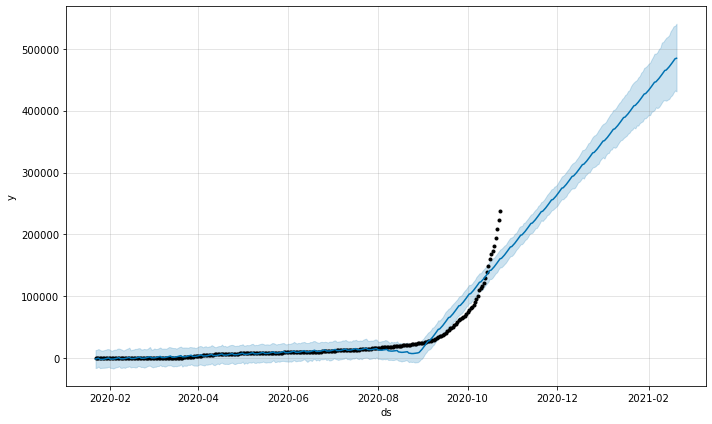

In [8]:
fig1 = m.plot(forecast)